<a href="https://colab.research.google.com/github/kiransree2002/Assessment/blob/main/case_study_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import confusion_matrix, classification_report

#Loadind Dataset

In [2]:
print(tf.config.list_physical_devices('GPU'))

[]


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1011s 6us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [4]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

#Data Augumentation

In [5]:
augmentation = tf.keras.Sequential([
    layers.Resizing(256, 256),
    layers.RandomCrop(224, 224),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
])

#Preprocessing

In [6]:
def train_preprocess(image, label):

    image = tf.cast(image, tf.float32)

    image = augmentation(image)

    image = preprocess_input(image)

    return image, tf.squeeze(label)

In [7]:
def test_preprocess(image, label):

    image = tf.cast(image, tf.float32)

    image = tf.image.resize(image, (224, 224))

    image = preprocess_input(image)

    return image, tf.squeeze(label)

In [8]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)
)

train_ds = (
    train_ds
    .shuffle(5000)
    .map(train_preprocess)
    .batch(32)
)

In [9]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (x_val, y_val)
)

val_ds = (
    val_ds
    .map(test_preprocess)
    .batch(32)
)
test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)
)

test_ds = (
    test_ds
    .map(test_preprocess)
    .batch(32)
)

#Load Pretrained ResNet50

In [10]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [11]:
base_model.trainable = False

In [12]:
model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        512,
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(0.0001)
    ),

    layers.BatchNormalization(),

    layers.ReLU(),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation='softmax'
    )
])
layers.GlobalAveragePooling2D()
layers.Dense(512)
kernel_initializer='he_normal'
kernel_regularizer=regularizers.l2(0.0001)
layers.BatchNormalization()

<BatchNormalization name=batch_normalization_1, built=False>

In [13]:
layers.ReLU()
layers.Dropout(0.5)
layers.Dense(10, activation='softmax')

<Dense name=dense_3, built=False>

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=0.001,
        weight_decay=0.0001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

In [16]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [17]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2,
    callbacks=[
        scheduler,
        checkpoint
    ]
)

# Freeze the pretrained layers
base_model.trainable = False

Epoch 1/2
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8473s 6s/step - accuracy: 0.7504 - loss: 0.8500 - val_accuracy: 0.8762 - val_loss: 0.4982 - learning_rate: 0.0010
Epoch 2/2
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8451s 6s/step - accuracy: 0.7956 - loss: 0.7343 - val_accuracy: 0.8890 - val_loss: 0.4745 - learning_rate: 0.0010


#Plots

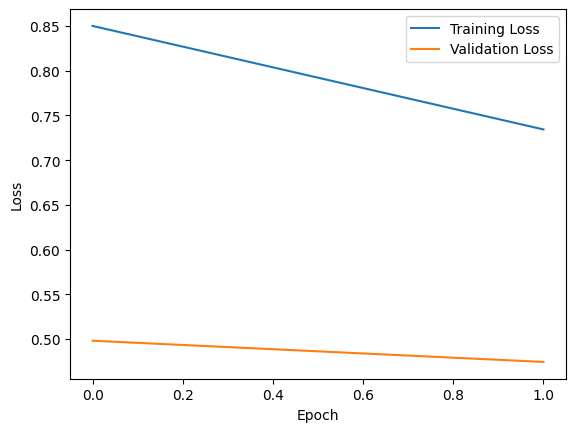

In [19]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

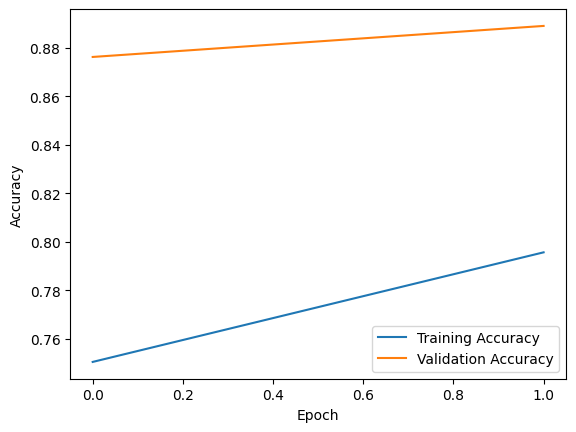

In [20]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [21]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=0.0001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
fine_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2,
    callbacks=[
        scheduler,
        early_stop,
        checkpoint
    ]
)

Epoch 1/2
  12/1407 ━━━━━━━━━━━━━━━━━━━━ 2:57:12 8s/step - accuracy: 0.8325 - loss: 0.5744

In [24]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1605s 5s/step - accuracy: 0.9068 - loss: 0.4239
Test Accuracy: 0.9067999720573425


In [25]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

#Classification Report

In [26]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.89      0.94      0.91      1000
  automobile       0.93      0.96      0.94      1000
        bird       0.91      0.88      0.89      1000
         cat       0.85      0.81      0.83      1000
        deer       0.87      0.90      0.89      1000
         dog       0.89      0.87      0.88      1000
        frog       0.92      0.94      0.93      1000
       horse       0.91      0.94      0.92      1000
        ship       0.95      0.93      0.94      1000
       truck       0.95      0.91      0.93      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



#Confusion Matrix

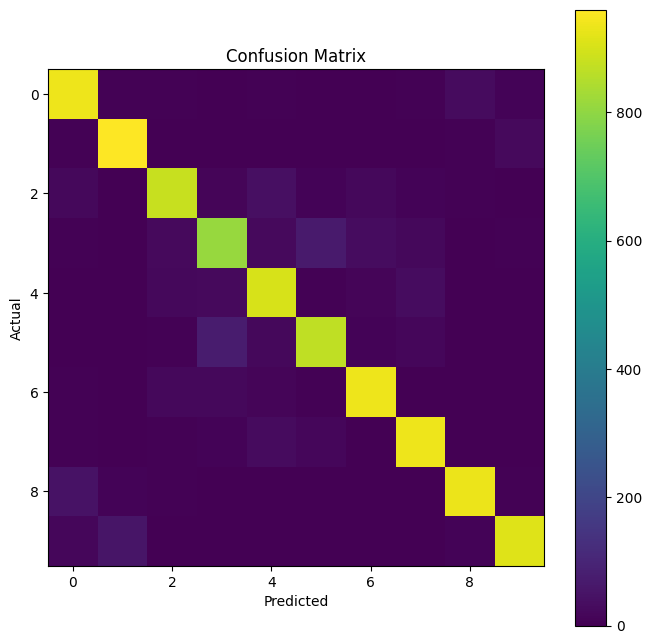

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))

plt.imshow(cm)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.colorbar()
plt.show()